# Minutes-adjusted association — does the signal survive holding playing time equal?
_Read-only diagnostic: compares each signal's raw rank-association with points to its association after partialling out `minutes`, per position, with bootstrap CIs; then checks whether it holds across minutes bands. **Association only — no causal/predictive claim.** DGW excluded._

**Sections:** (a) raw vs minutes-adjusted rho (with CIs) · (b) does it hold across minutes bands?

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded**; per position, leading-indicator universe (exact composites dropped). Raw and minutes-adjusted rho, plus their **paired shrinkage**, come from one **player-clustered** bootstrap (`cluster_bootstrap_minutes_adjusted_rho`) — players are resampled, not rows, because a player recurs every gameweek (matching `identity_vs_state.ipynb` / `panel.py`). Adjusted rho is a partial Spearman controlling for `minutes`. A CI-gated `verdict`: **minutes_proxy** (raw CI clears 0 but adjusted CI includes 0 → discard), **survives** (adjusted CI clears 0 and passes BH-FDR → real information), else **indeterminate**. Section (b) checks whether the link holds across minutes bands.

> **Confound vs mediator caveat.** For *process* signals (xG, xa) playing time is partly a **mediator** (a better player earns more minutes *and* more xG), not a pure confound — so the minutes-adjusted rho is a conservative *lower bound* on the real association, not a de-confounded truth. Association-only, single season (Pearl rung 1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.relevance import (
    compute_relevance, leading_indicator_signals, leading_alive_signals, POSITIONS,
)
from research.kernels.inferential.resampling import cluster_bootstrap_minutes_adjusted_rho
from research.kernels.hypothesis.multiplicity import benjamini_hochberg
from research.kernels.diagnostic.conditioning import (
    compute_conditional_rho, classify_heterogeneity,
)

POSITIONS = list(POSITIONS)
COLOURS = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
# verdict -> colour for the minutes-adjusted dot / row.
VERDICT_COLOURS = {"survives": "#1f77b4", "minutes_proxy": "#d62728", "indeterminate": "#bdbdbd"}

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

leading = sorted(leading_indicator_signals(drop_exact_composites=True))
alive_by_pos = {}
for p in POSITIONS:
    rel = compute_relevance(df[df["position"] == p], signals=leading, group_cols=())
    alive_by_pos[p] = leading_alive_signals(rel)

print(f"Study range: GW 1 - {_r.data_cutoff_gw} | minutes > 0 | DGW excluded | n = {len(df):,}")
for p in POSITIONS:
    print(f"  {p}: n={len(df[df.position == p]):>6,} | {len(alive_by_pos[p])} live signals")

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | n = 11,190
  GK: n=   747 | 3 live signals
  DEF: n= 3,845 | 9 live signals
  MID: n= 5,208 | 9 live signals
  FWD: n= 1,390 | 9 live signals


## (a) Raw vs minutes-adjusted rho
> The grey dot is the raw signal→points association; the coloured dot holds minutes equal. `shrinkage` (raw minus adjusted) is how much of the raw association was really just time on the pitch — "more minutes → more of every counting stat, and more points." Volume/accumulation stats shrink most (they can only be piled up by playing); chance-quality stats (xG, threat) hold up (one big chance registers even in limited minutes).

,position,signal,n,n_players,rho_raw,raw_ci,rho_adj,adj_ci,shrinkage,shrinkage_ci,adj_p,q_value,fdr_reject,verdict
6,DEF,influence,3845,183,0.5717,"(0.5428, 0.5982)",0.4176,"(0.3794, 0.4481)",0.1541,"(0.13, 0.1798)",0.0020,0.0029,True,survives
5,DEF,defensive_contribution,3845,183,0.4597,"(0.4261, 0.494)",0.2562,"(0.2116, 0.2999)",0.2035,"(0.1701, 0.2359)",0.0020,0.0029,True,survives
3,DEF,clearances_blocks_interceptions,3845,183,0.4419,"(0.4055, 0.476)",0.2403,"(0.1972, 0.2812)",0.2017,"(0.1706, 0.2309)",0.0020,0.0029,True,survives
9,DEF,threat,3845,183,0.2538,"(0.2182, 0.2865)",0.1460,"(0.1076, 0.1793)",0.1078,"(0.0854, 0.1307)",0.0020,0.0029,True,survives
7,DEF,recoveries,3845,183,0.2418,"(0.2016, 0.285)",0.0119,"(-0.0212, 0.0459)",0.2299,"(0.1984, 0.2619)",0.4655,0.4655,False,minutes_proxy
11,DEF,xg,3845,183,0.2245,"(0.1886, 0.2593)",0.1454,"(0.1086, 0.1816)",0.0791,"(0.0615, 0.0971)",0.0020,0.0029,True,survives
8,DEF,tackles,3845,183,0.2052,"(0.1728, 0.2376)",0.0602,"(0.0272, 0.0936)",0.1450,"(0.1205, 0.1724)",0.0020,0.0029,True,survives
10,DEF,xa,3845,183,0.2020,"(0.1651, 0.2403)",0.0656,"(0.0327, 0.0974)",0.1363,"(0.1113, 0.1627)",0.0020,0.0029,True,survives
4,DEF,creativity,3845,183,0.1903,"(0.1537, 0.2276)",0.0488,"(0.0149, 0.084)",0.1416,"(0.1133, 0.1734)",0.0060,0.0078,True,survives
24,FWD,influence,1390,66,0.7259,"(0.6707, 0.775)",0.6314,"(0.5683, 0.6916)",0.0944,"(0.0706, 0.1207)",0.0020,0.0029,True,survives


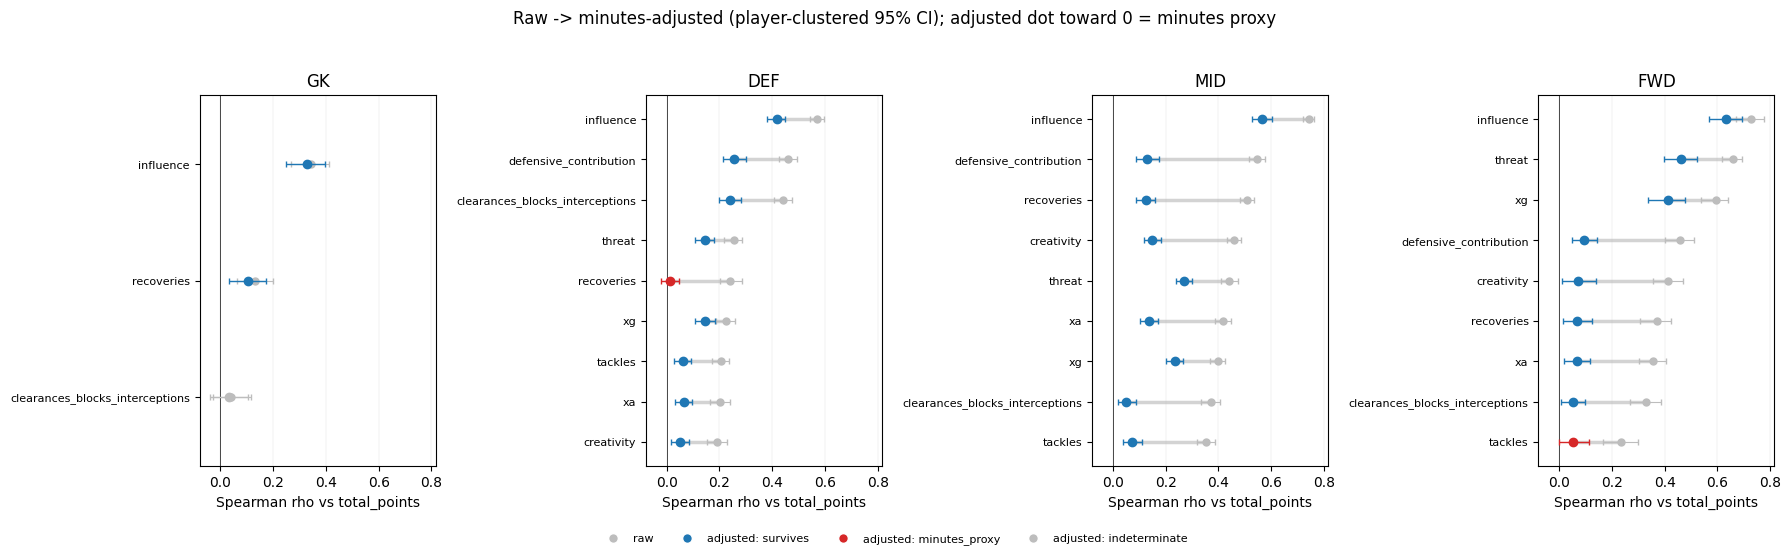

verdict counts:
verdict
survives         27
minutes_proxy     2
indeterminate     1


In [2]:
def _arrs(d, sig):
    pair = d[[sig, "minutes", "total_points", "player_id"]].dropna()
    return (pair[sig].to_numpy(float), pair["minutes"].to_numpy(float),
            pair["total_points"].to_numpy(float), pair["player_id"].to_numpy())

def _verdict(raw_ci, adj_ci, fdr_reject):
    # CI-gated: raw link real but vanishes under minutes -> proxy (discard);
    # survives the adjustment AND clears FDR -> real information; else can't tell.
    raw_real = not (raw_ci[0] <= 0 <= raw_ci[1])
    adj_real = not (adj_ci[0] <= 0 <= adj_ci[1])
    if adj_real and fdr_reject:
        return "survives"
    if raw_real and not adj_real:
        return "minutes_proxy"
    return "indeterminate"

# Player-clustered bootstrap: raw rho, minutes-adjusted (partial) rho, and their PAIRED
# shrinkage, all from one shared set of player resamples (rows within a player are not
# independent, so we resample players — matching identity_vs_state.ipynb / panel.py).
rows = []
for p in POSITIONS:
    d = df[df["position"] == p]
    for sig in alive_by_pos[p]:
        s, m, y, pid = _arrs(d, sig)
        out = cluster_bootstrap_minutes_adjusted_rho(s, m, y, pid)
        if out is None:
            continue
        rows.append({"position": p, "signal": sig, **out})
madj = pd.DataFrame(rows)

# BH-FDR across the screen on the clustered adjusted-rho p-value (the survivor's significance).
madj["fdr_reject"] = False
madj["q_value"] = np.nan
_has_p = madj["adj_p"].notna()
if _has_p.any():
    _fdr = benjamini_hochberg(madj.loc[_has_p, "adj_p"].to_numpy(), alpha=0.05)
    madj.loc[_has_p, "fdr_reject"] = _fdr["reject"]
    madj.loc[_has_p, "q_value"] = _fdr["q_value"]

madj["verdict"] = [
    _verdict(r.raw_ci, r.adj_ci, r.fdr_reject) for r in madj.itertuples()
]

_show = ["position", "signal", "n", "n_players", "rho_raw", "raw_ci", "rho_adj", "adj_ci",
         "shrinkage", "shrinkage_ci", "adj_p", "q_value", "fdr_reject", "verdict"]
display(madj[_show].sort_values(["position", "rho_raw"], ascending=[True, False]).round(4))

# Dumbbell per position: grey = raw (with CI), coloured-by-verdict = minutes-adjusted (with CI).
fig, axes = plt.subplots(1, 4, figsize=(18, 5.0), sharex=True)
for ax, p in zip(axes, POSITIONS):
    sub = madj[madj.position == p].sort_values("rho_raw")
    for y, r in enumerate(sub.itertuples()):
        vc = VERDICT_COLOURS.get(r.verdict, "#bdbdbd")
        ax.plot([r.rho_adj, r.rho_raw], [y, y], color="lightgrey", linewidth=2.5, zorder=1)
        ax.errorbar(r.rho_raw, y, xerr=[[r.rho_raw - r.raw_ci[0]], [r.raw_ci[1] - r.rho_raw]],
                    fmt="o", ms=5, color="#bdbdbd", ecolor="#bdbdbd", elinewidth=0.8, capsize=2, zorder=2)
        ax.errorbar(r.rho_adj, y, xerr=[[r.rho_adj - r.adj_ci[0]], [r.adj_ci[1] - r.rho_adj]],
                    fmt="o", ms=6, color=vc, ecolor=vc, elinewidth=1.0, capsize=2, zorder=3)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["signal"], fontsize=8)
    ax.set_ylim(-0.6, len(sub) - 0.4)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(p)
    ax.set_xlabel("Spearman rho vs total_points")
    ax.grid(axis="x", linewidth=0.3, alpha=0.4)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#bdbdbd", ms=7, label="raw"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor=VERDICT_COLOURS["survives"], ms=7, label="adjusted: survives"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor=VERDICT_COLOURS["minutes_proxy"], ms=7, label="adjusted: minutes_proxy"),
           Line2D([0], [0], marker="o", color="w", markerfacecolor=VERDICT_COLOURS["indeterminate"], ms=7, label="adjusted: indeterminate")]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Raw -> minutes-adjusted (player-clustered 95% CI); adjusted dot toward 0 = minutes proxy", y=1.03)
plt.tight_layout()
plt.show()

print("verdict counts:")
print(madj["verdict"].value_counts().to_string())

## (b) Does it hold across minutes bands?
> A signal that tracks points overall but reverses sign in a band is a trap. `compute_conditional_rho` reports rho within each minutes band (`1-29 / 30-59 / 60+`); `classify_heterogeneity` flags `heterogeneous_sign` (reverses) or `heterogeneous_magnitude` (holds direction, swings in strength).
>
> **Players-per-band guard (P3).** A band's rho is only trusted for classification when it rests on **≥ `MIN_PLAYERS_PER_BAND` distinct players**, not just ≥30 rows — the `1-29'` band is dominated by a handful of cameo appearances, so a sign-flip there is usually an artifact, not a real reversal. Under-populated bands (marked `*`) are shown for context but **excluded from the verdict**, so `heterogeneous_sign` now requires two *well-populated* bands to disagree.

In [3]:
MIN_PLAYERS_PER_BAND = 15  # distinct players a band needs before its rho counts toward the verdict

def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

dband = df.assign(band=df["minutes"].astype(int).map(_band))
het_rows = []
for p in POSITIONS:
    d = dband[dband["position"] == p]
    for sig in alive_by_pos[p]:
        cr = compute_conditional_rho(d, sig, "total_points", "band")
        # distinct players behind each band's rho (a row count of 30 can be < 15 players)
        pc = (d.dropna(subset=[sig, "total_points"]).groupby("band")["player_id"].nunique())
        cr["n_players"] = cr["stratum"].map(pc).fillna(0).astype(int)
        # guard: null out under-populated bands BEFORE classifying, so a cameo-driven
        # 1-29' sign-flip can't manufacture a 'heterogeneous_sign' trap.
        guarded = cr.copy()
        guarded.loc[guarded["n_players"] < MIN_PLAYERS_PER_BAND, "rho"] = np.nan
        row = {"position": p, "signal": sig, "verdict": classify_heterogeneity(guarded)}
        for r in cr.itertuples():
            mark = "" if r.n_players >= MIN_PLAYERS_PER_BAND else "*"
            row[f"rho[{r.stratum}]"] = r.rho
            row[f"np[{r.stratum}]"] = f"{r.n_players}{mark}"
        het_rows.append(row)
het_tbl = pd.DataFrame(het_rows)
display(het_tbl.sort_values(["position", "signal"]).round(4))
print("verdict counts (after players-per-band guard; * = band excluded from verdict):")
print(het_tbl["verdict"].value_counts().to_string())

,position,signal,verdict,rho[1-29],np[1-29],rho[30-59],np[30-59],rho[60+],np[60+]
3,DEF,clearances_blocks_interceptions,homogeneous,-0.0826,148,0.0694,137,0.2650,168
4,DEF,creativity,homogeneous,0.0142,148,0.0684,137,0.0137,168
5,DEF,defensive_contribution,heterogeneous_sign,-0.1135,148,0.0834,137,0.2747,168
6,DEF,influence,heterogeneous_magnitude,0.1658,148,0.3037,137,0.4127,168
7,DEF,recoveries,homogeneous,-0.1033,148,0.0384,137,-0.0144,168
8,DEF,tackles,homogeneous,-0.0607,148,0.0272,137,0.0475,168
9,DEF,threat,homogeneous,0.1726,148,0.1312,137,0.1321,168
10,DEF,xa,homogeneous,0.0875,148,0.0774,137,0.0400,168
11,DEF,xg,homogeneous,0.1834,148,0.0561,137,0.1393,168
21,FWD,clearances_blocks_interceptions,homogeneous,0.0650,62,0.0034,51,0.0425,52


verdict counts (after players-per-band guard; * = band excluded from verdict):
verdict
homogeneous                22
insufficient                3
heterogeneous_magnitude     3
heterogeneous_sign          2


## Summary — does the signal survive holding minutes equal?

**Why this matters.** Minutes are the biggest confound in the data: more time on the pitch mechanically means more of *every* counting stat **and** more points. So a raw signal→points correlation is partly just "players who are out there longer do more of everything." Holding minutes equal (partial Spearman) asks whether the signal still separates two **equally-played** players. If the link collapses to include 0, the stat was largely a stand-in for playing time.

**What Q2 is actually auditing.** `identity_vs_state.ipynb` (Q1b) showed these signals link to points overwhelmingly through *who the player is* — they **rank better players above worse players** (between-player), not hot weeks above cold ones. Q2 is the stress-test of *that* ranking: if a stat only ranks players well because it ranks *minutes* well, the ranking is hollow. It mostly is **not** hollow — shrinkage is real everywhere (minutes does inflate the raw number), but almost every signal keeps a significant association once minutes are held equal. So Q1b's identity story survives the audit.

**Why the pattern splits the way it does (accumulation vs quality).**
- **Accumulation / volume stats** (defensive_contribution, recoveries, tackles, CBI) can *only* be piled up by being on the pitch — minutes and the stat are nearly the same thing, so they **shrink hardest**, and two collapse entirely.
- **Chance-quality stats** (xG, threat, influence) can spike from a single big chance even in limited minutes, so they're **less a function of time** and hold most of their signal after adjustment.

**The exceptions (discard candidates).** Two signals collapse to a minutes proxy — their points link was mostly "on the pitch → racks up the count":
- **recoveries (DEF)** — adjusted CI includes 0 (shrinkage ≈ 0.23).
- **tackles (FWD)** — adjusted CI includes 0.

**Band trap (vetted, DEF & MID `defensive_contribution`).** It survives the overall adjustment but **reverses sign across minutes bands** — negative in `1-29'`, positive in `60+`. The players-per-band guard (§b) confirms this is **not** a cameo artifact: both bands rest on 140+ distinct players. Read it as regime-dependent (only pays with real minutes), not a clean monotone signal.

**GK**: `influence` and `recoveries` survive (small shrinkage); only `clearances_blocks_interceptions` is `indeterminate` — no real raw link, and its low-minute bands (4–6 players) are guarded out, so §b returns `insufficient`.

**Scope of the verdict — advisory, not an action.** This is a read-only diagnostic; it emits nothing into the `findings → registry → model` path. `DISCARD` means *don't trust the stat by eye and don't spend a validation slot on it* — not that anything is removed from the mart or the model. A binding drop only happens if the finding is re-derived in a `families/` validate study (lagged, out-of-sample, gated). Single season, association-only. The per-position routing below is generated from the table, not hard-coded.

In [4]:
# Manager-read, generated from section (a) + the band check (b). Derived, not hard-coded.
# Advisory triage only: this diagnostic emits nothing to the model. "DISCARD candidate" means
# don't trust it by eye / don't spend a validation slot on it — a binding drop needs a families/ study.
ROUTE = {"survives": "KEEP (info beyond minutes)", "minutes_proxy": "DISCARD candidate (minutes proxy)",
         "indeterminate": "can't tell (one season)"}
_traps = set(zip(het_tbl.loc[het_tbl.verdict == "heterogeneous_sign", "position"],
                 het_tbl.loc[het_tbl.verdict == "heterogeneous_sign", "signal"]))

print("MINUTES-ADJUSTED ASSOCIATION — per-position verdict (single season, association-only, advisory)\n")
for p in POSITIONS:
    sub = madj[madj.position == p].sort_values("rho_adj", ascending=False)
    n_keep = int((sub.verdict == "survives").sum())
    print(f"{p}:  {n_keep} of {len(sub)} survive minutes adjustment")
    for r in sub.itertuples():
        trap = "  ⚠ sign-flips across minutes bands" if (p, r.signal) in _traps else ""
        print(f"    {r.signal:<32} {r.verdict:<14} -> {ROUTE[r.verdict]:<32} "
              f"rho {r.rho_raw:.2f}->{r.rho_adj:.2f} (shrink {r.shrinkage:+.2f}){trap}")
    print()

print("DISCARD candidates (minutes proxies):",
      ", ".join(f"{r.signal}({r.position})" for r in madj[madj.verdict == 'minutes_proxy'].itertuples()) or "none")
print("Advisory only — nothing is emitted to the model; a binding drop requires a families/ validate study.")
print("Adjusted rho is a conservative lower bound for process signals (minutes is partly a mediator, not a pure confound).")

MINUTES-ADJUSTED ASSOCIATION — per-position verdict (single season, association-only, advisory)

GK:  2 of 3 survive minutes adjustment
    influence                        survives       -> KEEP (info beyond minutes)       rho 0.34->0.33 (shrink +0.02)
    recoveries                       survives       -> KEEP (info beyond minutes)       rho 0.13->0.10 (shrink +0.03)
    clearances_blocks_interceptions  indeterminate  -> can't tell (one season)          rho 0.04->0.03 (shrink +0.01)

DEF:  8 of 9 survive minutes adjustment
    influence                        survives       -> KEEP (info beyond minutes)       rho 0.57->0.42 (shrink +0.15)
    defensive_contribution           survives       -> KEEP (info beyond minutes)       rho 0.46->0.26 (shrink +0.20)  ⚠ sign-flips across minutes bands
    clearances_blocks_interceptions  survives       -> KEEP (info beyond minutes)       rho 0.44->0.24 (shrink +0.20)
    threat                           survives       -> KEEP (info beyond minutes